# What is the most optimal skill to learn for Data Analysts?

## Methodology

1. Group skills to determine median salary and likelihood of being in posting  
2. Visualize median salary vs percent skill demand  
3. (Optional) Determine if certain technologies are more prevalent

In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()


In [3]:
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

df_DA_US_exploded = df_DA_US.explode('job_skills')

df_DA_US_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [6]:
df_DA_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

,count,median
job_skills,,
sql,2508,91000.0
excel,1808,84392.0
python,1431,97500.0
tableau,1364,92875.0
sas,926,90000.0
...,...,...
theano,1,100000.0
typescript,1,65000.0
vmware,1,147500.0


In [12]:
df_DA_skills = df_DA_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_DA_skills = df_DA_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})
DA_job_count = len(df_DA_US)

df_DA_skills['skill_percent'] = df_DA_skills['skill_count'] / DA_job_count * 100


skill_percent = 5

df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_percent'] > skill_percent]

df_DA_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


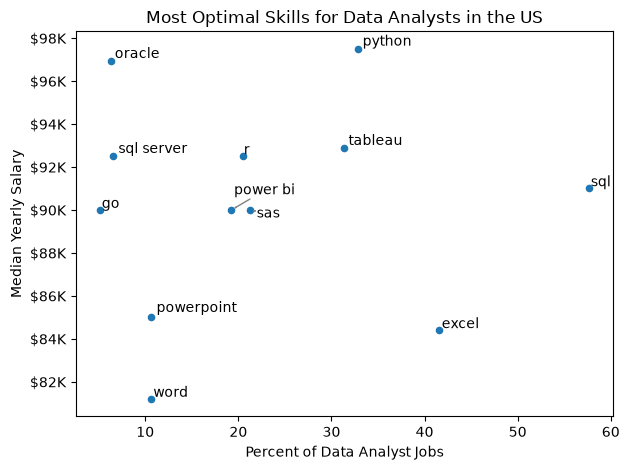

In [18]:
from adjustText import adjust_text
from matplotlib.ticker import FuncFormatter  # optional, but cleaner

df_DA_skills_high_demand.plot(kind='scatter', x='skill_percent', y='median_salary')

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(
        df_DA_skills_high_demand['skill_percent'].iloc[i],
        df_DA_skills_high_demand['median_salary'].iloc[i],
        txt
    ))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title, and legend
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the US')

# Format y‑axis as dollars ($XXK)
ax = plt.gca()
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'${int(y/1000)}K')
)

# Adjust layout and display plot
plt.tight_layout()
plt.show()

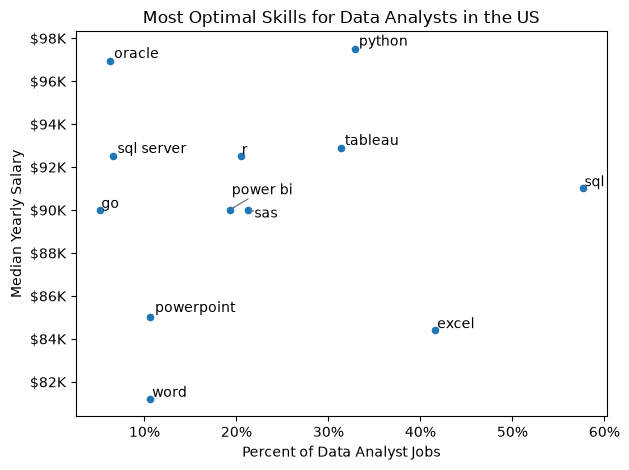

In [21]:
from adjustText import adjust_text
from matplotlib.ticker import FuncFormatter, PercentFormatter

# Create the scatter plot
df_DA_skills_high_demand.plot(kind='scatter', x='skill_percent', y='median_salary')

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(
        df_DA_skills_high_demand['skill_percent'].iloc[i],
        df_DA_skills_high_demand['median_salary'].iloc[i],
        txt                      # ← fixed: added the missing closing parenthesis
    ))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title, and legend
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the US')

# Format both axes
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))  # ← fixed: 'decimals', not 'decimalplaces'

# Adjust layout and display plot
plt.tight_layout()
plt.show()

In [22]:
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)  # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists in technology_dict, add value to existing value
            technology_dict[key] += value
        else:                       # if key does not exist in technology_dict, add key and value
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict


{'analyst_tools': ['microstrategy',
  'spss',
  'powerbi',
  'tableau',
  'word',
  'visio',
  'nuix',
  'alteryx',
  'splunk',
  'excel',
  'ms access',
  'sap',
  'msaccess',
  'sharepoint',
  'qlik',
  'outlook',
  'ssis',
  'looker',
  'dax',
  'cognos',
  'powerpoint',
  'power bi',
  'ssrs',
  'esquisse',
  'datarobot',
  'spreadsheet',
  'sas',
  'sheets'],
 'programming': ['ocaml',
  'f#',
  'golang',
  'kotlin',
  'dart',
  'c++',
  'vba',
  'solidity',
  'elixir',
  'perl',
  'haskell',
  'sql',
  'c',
  'swift',
  'javascript',
  'visualbasic',
  'shell',
  'fortran',
  'rust',
  'typescript',
  'pascal',
  'go',
  'bash',
  'cobol',
  'powershell',
  'apl',
  'lisp',
  'mongodb',
  't-sql',
  'java',
  'php',
  'r',
  'erlang',
  'delphi',
  'html',
  'objective-c',
  'julia',
  'crystal',
  'c#',
  'visual basic',
  'matlab',
  'no-sql',
  'nosql',
  'scala',
  'lua',
  'groovy',
  'vb.net',
  'assembly',
  'clojure',
  'ruby',
  'sass',
  'mongo',
  'css',
  'sas',
  'pyt

In [23]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,microstrategy
0,analyst_tools,spss
0,analyst_tools,powerbi
0,analyst_tools,tableau
0,analyst_tools,word
...,...,...
9,sync,google chat
9,sync,wire
9,sync,zoom
9,sync,unify


In [24]:
df_DA_skills_high_demand.merge(df_technology, left_on='job_skills', right_on='skills')

,skill_count,median_salary,skill_percent,technology,skills
0,2508,91000.00,57.655172,programming,sql
1,1808,84392.00,41.563218,analyst_tools,excel
2,1431,97500.00,32.896552,programming,python
3,1364,92875.00,31.356322,analyst_tools,tableau
4,926,90000.00,21.287356,analyst_tools,sas
5,926,90000.00,21.287356,programming,sas
6,893,92500.00,20.528736,programming,r
7,838,90000.00,19.264368,analyst_tools,power bi
8,462,85000.00,10.620690,analyst_tools,powerpoint
9,461,81194.75,10.597701,analyst_tools,word


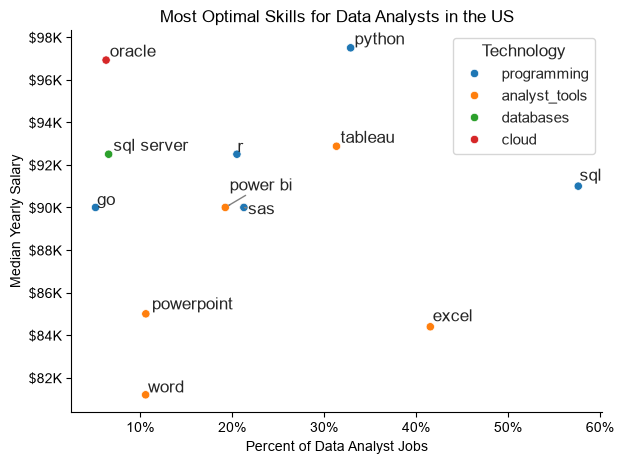

In [28]:
from adjustText import adjust_text
from matplotlib.ticker import FuncFormatter, PercentFormatter

# Create the merged DataFrame
df_DA_skills_tech_high_demand = df_DA_skills_high_demand.merge(
    df_technology,
    left_on='job_skills',
    right_on='skills'
)

# Create the scatter plot with hue
sns.scatterplot(
    data=df_DA_skills_tech_high_demand,
    x='skill_percent',
    y='median_salary',
    hue='technology'
)

sns.despine()
sns.set_theme(style='ticks')

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(
        df_DA_skills_high_demand['skill_percent'].iloc[i],
        df_DA_skills_high_demand['median_salary'].iloc[i],
        txt
    ))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title, and legend
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the US')
plt.legend(title='Technology')

# Format both axes
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))  # ← 'decimals', not 'decimal'

# Adjust layout and display plot
plt.tight_layout()
plt.show()